In [1]:
import r
import algorithm
from render import render_static

In [2]:
r_function = (
    r.Box(size=(0.2, 0.2, 0.2)) & ~r.CylinderZ(radius=0.1, height=8.0)
)

In [3]:
def process_r_function(fun, resolution):
    algorithms = [
        (
            "Marching Cubes, Lewiner",
            algorithm.MarchingCubes,
            {"resolution": resolution, "method": "lewiner"}
        ),
        (
            "Marching Cubes, Lorensen",
            algorithm.MarchingCubes,
            {"resolution": resolution, "method": "lorensen"}
        ),
        (
            "FlexiCubes, no gradient",
            algorithm.FlexiCubes,
            {"resolution": resolution, "iterations": 1}
        ),
        (
            "FlexiCubes, learn from random",
            algorithm.FlexiCubes,
            {"resolution": resolution, "iterations": 400}
        ),
    ]
    for title, Algorithm, settings in algorithms:
        print("Processing: ", title)
        algo = Algorithm(settings)
        algo.fit(fun)
        render_static(algo.mesh)
        print(algo.meta)

Processing:  Marching Cubes, Lewiner


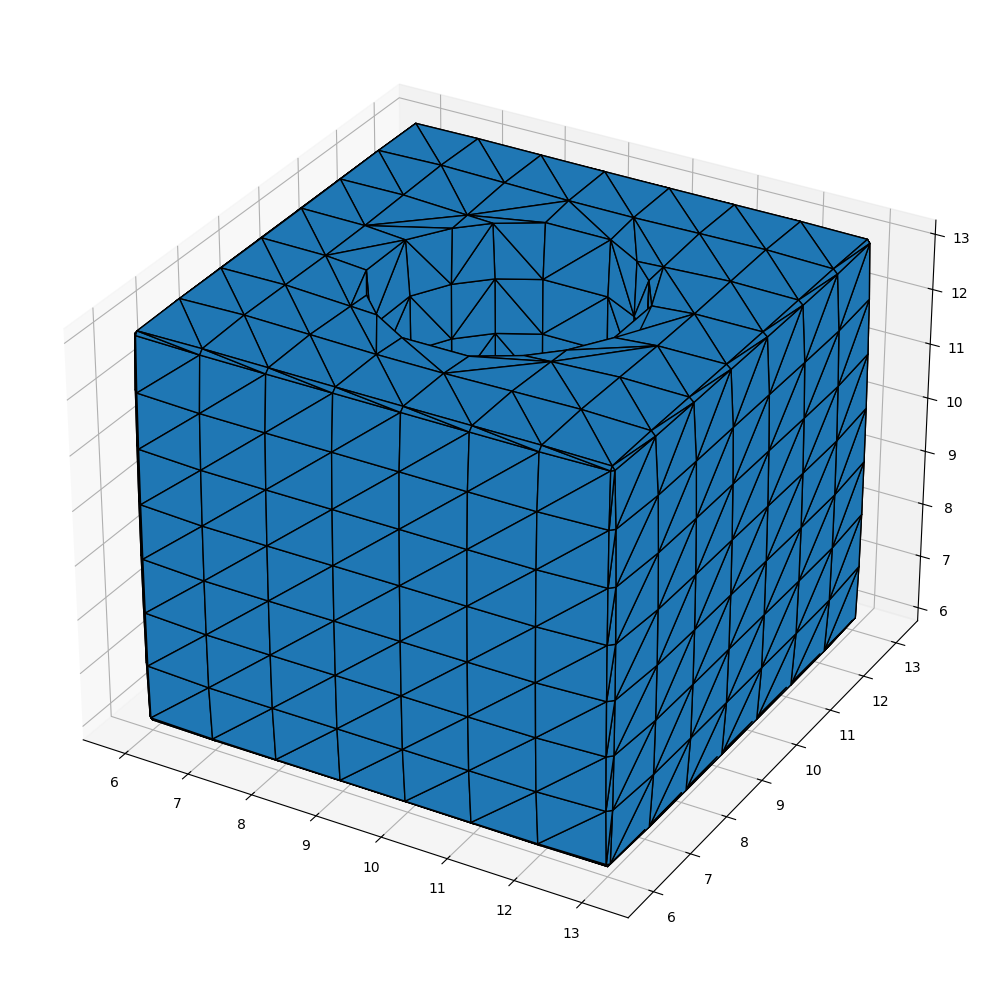

FitMeta(elapsed_time_seconds=0.0026105419965460896)
Processing:  Marching Cubes, Lorensen


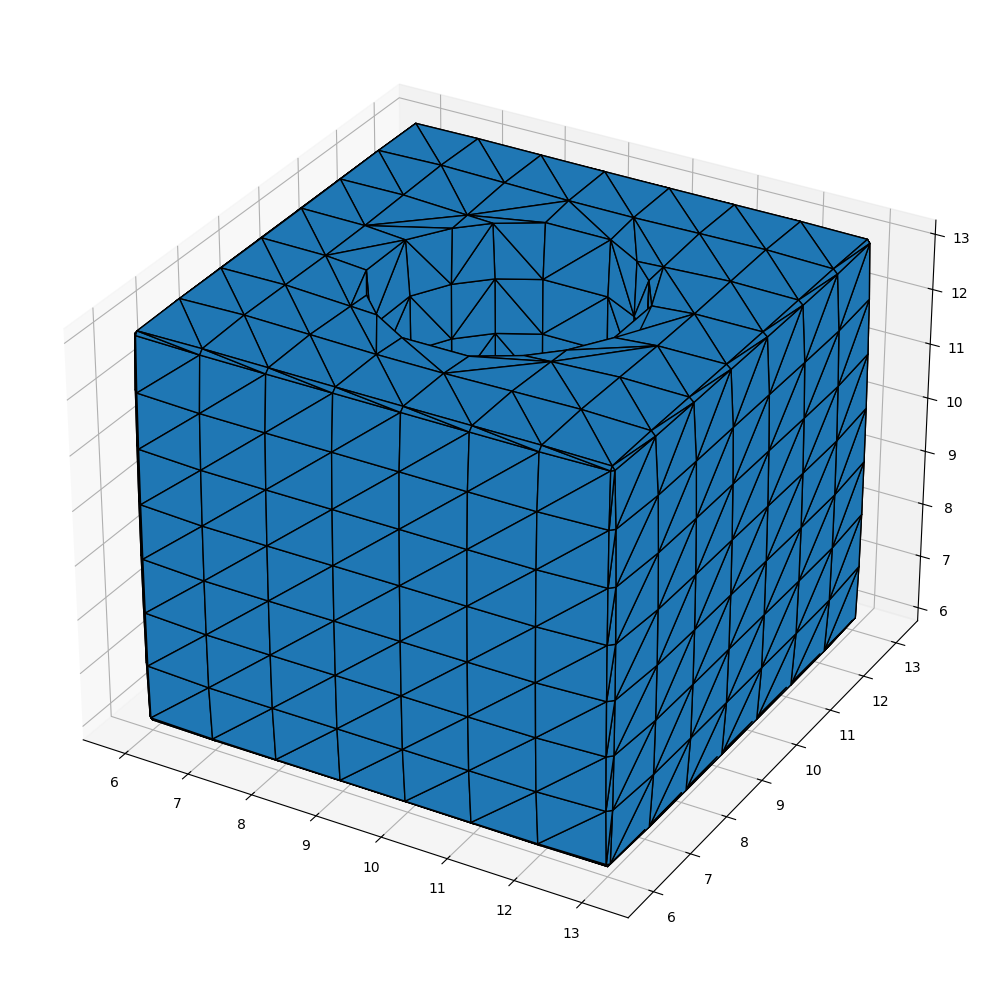

FitMeta(elapsed_time_seconds=0.0006630830466747284)
Processing:  FlexiCubes, no gradient


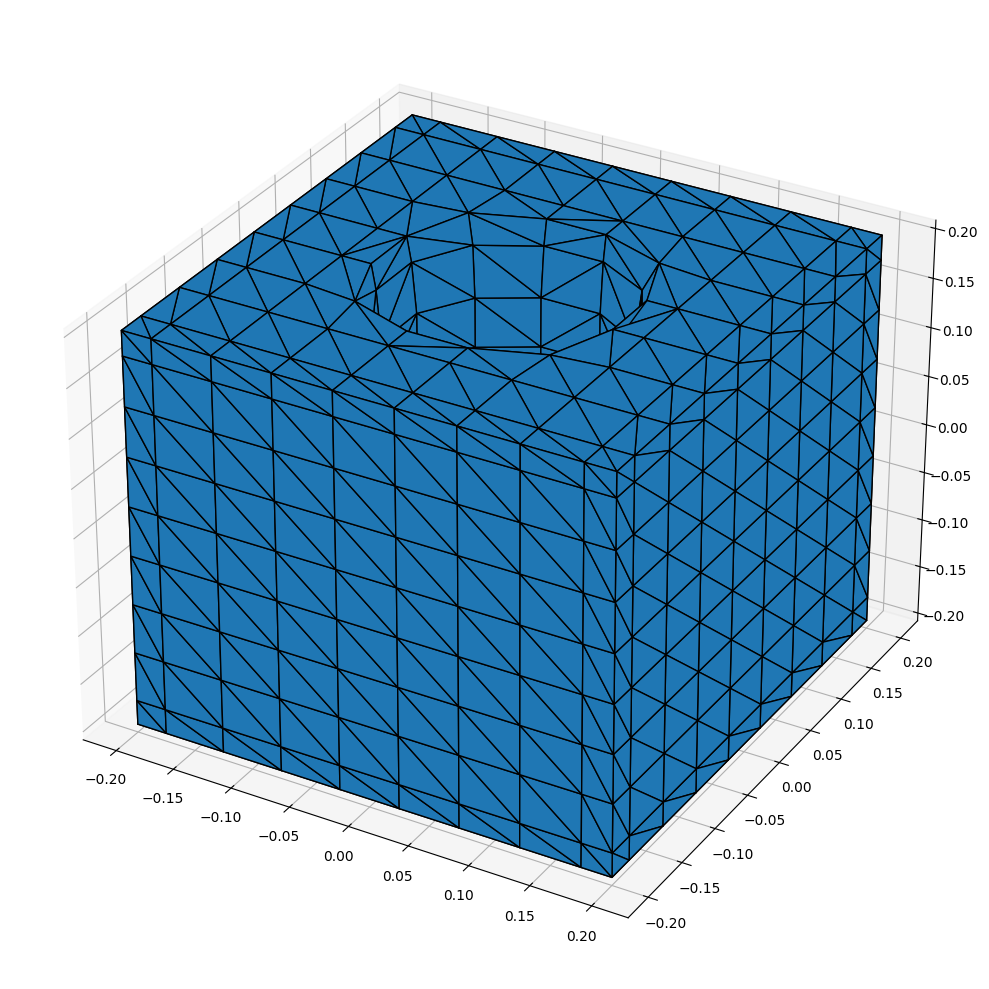

FitMeta(elapsed_time_seconds=0.08348841697443277)
Processing:  FlexiCubes, learn from random


100%|███████████████████████████████████████████████████████████████████| 400/400 [00:07<00:00, 52.87it/s]


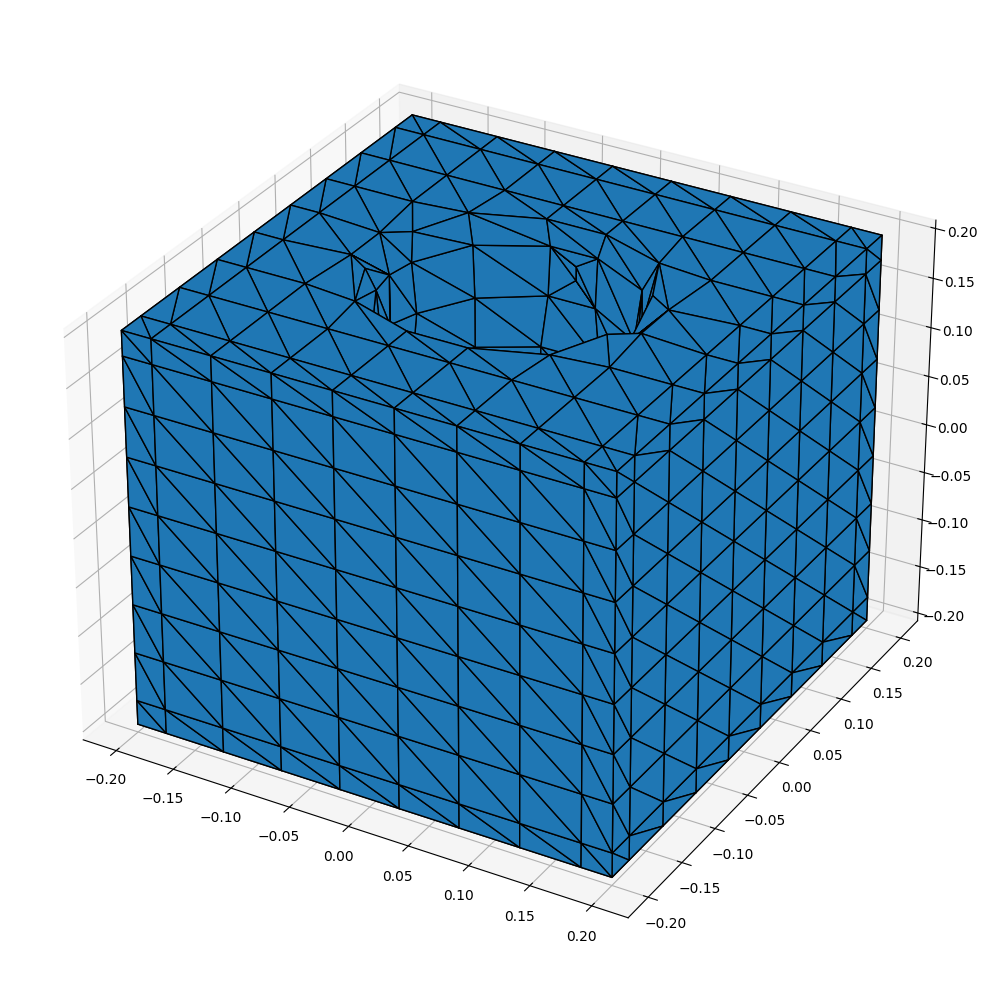

FitMeta(elapsed_time_seconds=8.336338208988309)


In [4]:
process_r_function(r_function, 20)